# InstantID: Zero-shot Identity-Preserving Generation using OpenVINO

Nowadays has been significant progress in personalized image synthesis with methods such as Textual Inversion, DreamBooth, and LoRA.
However, their real-world applicability is hindered by high storage demands, lengthy fine-tuning processes, and the need for multiple reference images. Conversely, existing ID embedding-based methods, while requiring only a single forward inference, face challenges: they either necessitate extensive fine-tuning across numerous model parameters, lack compatibility with community pre-trained models, or fail to maintain high face fidelity. 

[InstantID](https://instantid.github.io/) is a tuning-free method to achieve ID-Preserving generation with only single image, supporting various downstream tasks.
![applications.png](https://github.com/InstantID/InstantID/blob/main/assets/applications.png?raw=true)

Given only one reference ID image, InstantID aims to generate customized images with various poses or styles from a single reference ID image while ensuring high fidelity. Following figure provides an overview of the method. It incorporates three crucial components: 

1. An ID embedding that captures robust semantic face information; 
2. A lightweight adapted module with decoupled cross-attention, facilitating the use of an image as a visual prompt;
3. An IdentityNet that encodes the detailed features from the reference facial image with additional spatial control.

![instantid-components.png](https://instantid.github.io/static/documents/pipeline.png)

The difference InstantID from previous works in the following aspects: 
1. do not involve UNet training, so it can preserve the generation ability of the original text-to-image model and be compatible with existing pre-trained models and ControlNets in the community;
2. doesn't require test-time tuning, so for a specific character, there is no need to collect multiple images for fine-tuning, only a single image needs to be inferred once;
3. achieve better face fidelity, and retain the editability of text.

You can find more details about the approach with [project web page](https://instantid.github.io/), [paper](https://arxiv.org/abs/2401.07519) and [original repository](https://github.com/InstantID/InstantID)

In this tutorial, we consider how to use InstantID with OpenVINO. An additional part demonstrates how to run optimization with [NNCF](https://github.com/openvinotoolkit/nncf/) to speed up pipeline.
#### Table of contents:
- [Prerequisites](#Prerequisites)
- [Convert and prepare Face IdentityNet](#Convert-and-prepare-Face-IdentityNet)
    - [Select Inference Device for Face Recognition](#Select-Inference-Device-for-Face-Recognition)
    - [Perform Face Identity extraction](#Perform-Face-Identity-extraction)
- [Prepare InstantID pipeline](#Prepare-InstantID-pipeline)
- [Convert InstantID pipeline components to OpenVINO Intermediate Representation format](#Convert-InstantID-pipeline-components-to-OpenVINO-Intermediate-Representation-format)
    - [ControlNet](#ControlNet)
    - [Unet](#Unet)
    - [VAE Decoder](#VAE-Decoder)
    - [Text Encoders](#Text-Encoders)
    - [Image Projection Model](#Image-Projection-Model)
- [Prepare OpenVINO InstantID Pipeline](#Prepare-OpenVINO-InstantID-Pipeline)
- [Run OpenVINO pipeline inference](#Run-OpenVINO-pipeline-inference)
    - [Select inference device for InstantID](#Select-inference-device-for-InstantID)
    - [Create pipeline](#Create-pipeline)
    - [Run inference](#Run-inference)
- [Quantization](#Quantization)
    - [Prepare calibration datasets](#Prepare-calibration-datasets)
    - [Run quantization](#Run-quantization)
        - [Run ControlNet Quantization](#Run-ControlNet-Quantization)
        - [Run UNet Hybrid Quantization](#Run-UNet-Hybrid-Quantization)
        - [Run Weights Compression](#Run-Weights-Compression)
    - [Compare model file sizes](#Compare-model-file-sizes)
    - [Compare inference time of the FP16 and INT8 pipelines](#Compare-inference-time-of-the-FP16-and-INT8-pipelines)
- [Interactive demo](#Interactive-demo)

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/instant-id/instant-id.ipynb" />


## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [ ]:
import requests
from pathlib import Path

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

if not Path("cmd_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py",
    )
    open("cmd_helper.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("instant-id.ipynb")

In [ ]:
from cmd_helper import clone_repo


clone_repo("https://github.com/InstantID/InstantID.git")

In [ ]:
%pip install -q "openvino>=2023.3.0" opencv-python transformers "diffusers>=0.24.0" "matplotlib>=3.4" accelerate gdown "scikit-image>=0.19.2" "gradio>=4.19" "nncf>=2.9.0" "datasets>=2.14.6" "peft>=0.6.2"

## Convert and prepare Face IdentityNet
[back to top ⬆️](#Table-of-contents:)

For getting face embeddings and pose key points, InstantID uses [InsightFace](https://github.com/deepinsight/insightface) face analytic library. Its models are distributed in ONNX format and can be run with OpenVINO.
For preparing the face image, we need to detect the bounding boxes and keypoints for the face using the RetinaFace model, crop the detected face, align the face location using landmarks, and provide each face into the Arcface face embedding model for getting the person's identity embeddings.

The code below downloads the InsightFace Antelopev2 model kit and provides a simple interface compatible with InsightFace for getting face recognition results.

In [ ]:
from pathlib import Path


MODELS_DIR = Path("models")
face_detector_path = MODELS_DIR / "antelopev2" / "scrfd_10g_bnkps.onnx"
face_embeddings_path = MODELS_DIR / "antelopev2" / "glintr100.onnx"

In [4]:
from zipfile import ZipFile
import gdown

archive_file = Path("antelopev2.zip")

if not face_detector_path.exists() or face_embeddings_path.exists():
    if not archive_file.exists():
        gdown.download(
            "https://drive.google.com/uc?id=18wEUfMNohBJ4K3Ly5wpTejPfDzp-8fI8",
            str(archive_file),
        )
    with ZipFile(archive_file, "r") as zip_face_models:
        zip_face_models.extractall(MODELS_DIR)

In [5]:
import cv2
import numpy as np
from skimage import transform as trans


def softmax(z):
    assert len(z.shape) == 2
    s = np.max(z, axis=1)
    s = s[:, np.newaxis]  # necessary step to do broadcasting
    e_x = np.exp(z - s)
    div = np.sum(e_x, axis=1)
    div = div[:, np.newaxis]  # dito
    return e_x / div


def distance2bbox(points, distance, max_shape=None):
    """Decode distance prediction to bounding box.

    Args:
        points (Tensor): Shape (n, 2), [x, y].
        distance (Tensor): Distance from the given point to 4
            boundaries (left, top, right, bottom).
        max_shape (tuple): Shape of the image.

    Returns:
        Tensor: Decoded bboxes.
    """
    x1 = points[:, 0] - distance[:, 0]
    y1 = points[:, 1] - distance[:, 1]
    x2 = points[:, 0] + distance[:, 2]
    y2 = points[:, 1] + distance[:, 3]
    if max_shape is not None:
        x1 = x1.clamp(min=0, max=max_shape[1])
        y1 = y1.clamp(min=0, max=max_shape[0])
        x2 = x2.clamp(min=0, max=max_shape[1])
        y2 = y2.clamp(min=0, max=max_shape[0])
    return np.stack([x1, y1, x2, y2], axis=-1)


def distance2kps(points, distance, max_shape=None):
    """Decode distance prediction to bounding box.

    Args:
        points (Tensor): Shape (n, 2), [x, y].
        distance (Tensor): Distance from the given point to 4
            boundaries (left, top, right, bottom).
        max_shape (tuple): Shape of the image.

    Returns:
        Tensor: Decoded bboxes.
    """
    preds = []
    for i in range(0, distance.shape[1], 2):
        px = points[:, i % 2] + distance[:, i]
        py = points[:, i % 2 + 1] + distance[:, i + 1]
        if max_shape is not None:
            px = px.clamp(min=0, max=max_shape[1])
            py = py.clamp(min=0, max=max_shape[0])
        preds.append(px)
        preds.append(py)
    return np.stack(preds, axis=-1)


def prepare_input(image, std, mean, reverse_channels=True):
    normalized_image = (image.astype(np.float32) - mean) / std
    if reverse_channels:
        normalized_image = normalized_image[:, :, ::-1]
    input_tensor = np.expand_dims(np.transpose(normalized_image, (2, 0, 1)), 0)
    return input_tensor


class RetinaFace:
    def __init__(self, ov_model):
        self.taskname = "detection"
        self.ov_model = ov_model
        self.center_cache = {}
        self.nms_thresh = 0.4
        self.det_thresh = 0.5
        self._init_vars()

    def _init_vars(self):
        self.input_size = (640, 640)
        outputs = self.ov_model.outputs
        self.input_mean = 127.5
        self.input_std = 128.0
        self.use_kps = False
        self._anchor_ratio = 1.0
        self._num_anchors = 1
        if len(outputs) == 6:
            self.fmc = 3
            self._feat_stride_fpn = [8, 16, 32]
            self._num_anchors = 2
        elif len(outputs) == 9:
            self.fmc = 3
            self._feat_stride_fpn = [8, 16, 32]
            self._num_anchors = 2
            self.use_kps = True
        elif len(outputs) == 10:
            self.fmc = 5
            self._feat_stride_fpn = [8, 16, 32, 64, 128]
            self._num_anchors = 1
        elif len(outputs) == 15:
            self.fmc = 5
            self._feat_stride_fpn = [8, 16, 32, 64, 128]
            self._num_anchors = 1
            self.use_kps = True

    def prepare(self, **kwargs):
        nms_thresh = kwargs.get("nms_thresh", None)
        if nms_thresh is not None:
            self.nms_thresh = nms_thresh
        det_thresh = kwargs.get("det_thresh", None)
        if det_thresh is not None:
            self.det_thresh = det_thresh
        input_size = kwargs.get("input_size", None)
        if input_size is not None:
            if self.input_size is not None:
                print("warning: det_size is already set in detection model, ignore")
            else:
                self.input_size = input_size

    def forward(self, img, threshold):
        scores_list = []
        bboxes_list = []
        kpss_list = []
        blob = prepare_input(img, self.input_mean, self.input_std, True)
        net_outs = self.ov_model(blob)

        input_height = blob.shape[2]
        input_width = blob.shape[3]
        fmc = self.fmc
        for idx, stride in enumerate(self._feat_stride_fpn):
            scores = net_outs[idx]
            bbox_preds = net_outs[idx + fmc]
            bbox_preds = bbox_preds * stride
            if self.use_kps:
                kps_preds = net_outs[idx + fmc * 2] * stride
            height = input_height // stride
            width = input_width // stride
            key = (height, width, stride)
            if key in self.center_cache:
                anchor_centers = self.center_cache[key]
            else:
                anchor_centers = np.stack(np.mgrid[:height, :width][::-1], axis=-1).astype(np.float32)
                anchor_centers = (anchor_centers * stride).reshape((-1, 2))
                if self._num_anchors > 1:
                    anchor_centers = np.stack([anchor_centers] * self._num_anchors, axis=1).reshape((-1, 2))
                if len(self.center_cache) < 100:
                    self.center_cache[key] = anchor_centers

            pos_inds = np.where(scores >= threshold)[0]
            bboxes = distance2bbox(anchor_centers, bbox_preds)
            pos_scores = scores[pos_inds]
            pos_bboxes = bboxes[pos_inds]
            scores_list.append(pos_scores)
            bboxes_list.append(pos_bboxes)
            if self.use_kps:
                kpss = distance2kps(anchor_centers, kps_preds)
                # kpss = kps_preds
                kpss = kpss.reshape((kpss.shape[0], -1, 2))
                pos_kpss = kpss[pos_inds]
                kpss_list.append(pos_kpss)
        return scores_list, bboxes_list, kpss_list

    def detect(self, img, input_size=None, max_num=0, metric="default"):
        assert input_size is not None or self.input_size is not None
        input_size = self.input_size if input_size is None else input_size

        im_ratio = float(img.shape[0]) / img.shape[1]
        model_ratio = float(input_size[1]) / input_size[0]
        if im_ratio > model_ratio:
            new_height = input_size[1]
            new_width = int(new_height / im_ratio)
        else:
            new_width = input_size[0]
            new_height = int(new_width * im_ratio)
        det_scale = float(new_height) / img.shape[0]
        resized_img = cv2.resize(img, (new_width, new_height))
        det_img = np.zeros((input_size[1], input_size[0], 3), dtype=np.uint8)
        det_img[:new_height, :new_width, :] = resized_img

        scores_list, bboxes_list, kpss_list = self.forward(det_img, self.det_thresh)

        scores = np.vstack(scores_list)
        scores_ravel = scores.ravel()
        order = scores_ravel.argsort()[::-1]
        bboxes = np.vstack(bboxes_list) / det_scale
        if self.use_kps:
            kpss = np.vstack(kpss_list) / det_scale
        pre_det = np.hstack((bboxes, scores)).astype(np.float32, copy=False)
        pre_det = pre_det[order, :]
        keep = self.nms(pre_det)
        det = pre_det[keep, :]
        if self.use_kps:
            kpss = kpss[order, :, :]
            kpss = kpss[keep, :, :]
        else:
            kpss = None
        if max_num > 0 and det.shape[0] > max_num:
            area = (det[:, 2] - det[:, 0]) * (det[:, 3] - det[:, 1])
            img_center = img.shape[0] // 2, img.shape[1] // 2
            offsets = np.vstack(
                [
                    (det[:, 0] + det[:, 2]) / 2 - img_center[1],
                    (det[:, 1] + det[:, 3]) / 2 - img_center[0],
                ]
            )
            offset_dist_squared = np.sum(np.power(offsets, 2.0), 0)
            if metric == "max":
                values = area
            else:
                values = area - offset_dist_squared * 2.0  # some extra weight on the centering
            bindex = np.argsort(values)[::-1]  # some extra weight on the centering
            bindex = bindex[0:max_num]
            det = det[bindex, :]
            if kpss is not None:
                kpss = kpss[bindex, :]
        return det, kpss

    def nms(self, dets):
        thresh = self.nms_thresh
        x1 = dets[:, 0]
        y1 = dets[:, 1]
        x2 = dets[:, 2]
        y2 = dets[:, 3]
        scores = dets[:, 4]

        areas = (x2 - x1 + 1) * (y2 - y1 + 1)
        order = scores.argsort()[::-1]

        keep = []
        while order.size > 0:
            i = order[0]
            keep.append(i)
            xx1 = np.maximum(x1[i], x1[order[1:]])
            yy1 = np.maximum(y1[i], y1[order[1:]])
            xx2 = np.minimum(x2[i], x2[order[1:]])
            yy2 = np.minimum(y2[i], y2[order[1:]])

            w = np.maximum(0.0, xx2 - xx1 + 1)
            h = np.maximum(0.0, yy2 - yy1 + 1)
            inter = w * h
            ovr = inter / (areas[i] + areas[order[1:]] - inter)

            inds = np.where(ovr <= thresh)[0]
            order = order[inds + 1]

        return keep


arcface_dst = np.array(
    [
        [38.2946, 51.6963],
        [73.5318, 51.5014],
        [56.0252, 71.7366],
        [41.5493, 92.3655],
        [70.7299, 92.2041],
    ],
    dtype=np.float32,
)


def estimate_norm(lmk, image_size=112, mode="arcface"):
    assert lmk.shape == (5, 2)
    assert image_size % 112 == 0 or image_size % 128 == 0
    if image_size % 112 == 0:
        ratio = float(image_size) / 112.0
        diff_x = 0
    else:
        ratio = float(image_size) / 128.0
        diff_x = 8.0 * ratio
    dst = arcface_dst * ratio
    dst[:, 0] += diff_x
    tform = trans.SimilarityTransform()
    tform.estimate(lmk, dst)
    M = tform.params[0:2, :]
    return M


def norm_crop(img, landmark, image_size=112, mode="arcface"):
    M = estimate_norm(landmark, image_size, mode)
    warped = cv2.warpAffine(img, M, (image_size, image_size), borderValue=0.0)
    return warped


class FaceEmbeddings:
    def __init__(self, ov_model):
        self.ov_model = ov_model
        self.taskname = "recognition"
        input_mean = 127.5
        input_std = 127.5
        self.input_mean = input_mean
        self.input_std = input_std
        input_shape = self.ov_model.inputs[0].partial_shape
        self.input_size = (input_shape[3].get_length(), input_shape[2].get_length())
        self.input_shape = input_shape

    def get(self, img, kps):
        aimg = norm_crop(img, landmark=kps, image_size=self.input_size[0])
        embedding = self.get_feat(aimg).flatten()
        return embedding

    def get_feat(self, imgs):
        if not isinstance(imgs, list):
            imgs = [imgs]
        input_size = self.input_size
        blob = np.concatenate([prepare_input(cv2.resize(img, input_size), self.input_mean, self.input_std, True) for img in imgs])

        net_out = self.ov_model(blob)[0]
        return net_out

    def forward(self, batch_data):
        blob = (batch_data - self.input_mean) / self.input_std
        net_out = self.ov_model(blob)[0]
        return net_out


class OVFaceAnalysis:
    def __init__(self, detect_model, embedding_model):
        self.det_model = RetinaFace(detect_model)
        self.embed_model = FaceEmbeddings(embedding_model)

    def get(self, img, max_num=0):
        bboxes, kpss = self.det_model.detect(img, max_num=max_num, metric="default")
        if bboxes.shape[0] == 0:
            return []
        ret = []
        for i in range(bboxes.shape[0]):
            bbox = bboxes[i, 0:4]
            det_score = bboxes[i, 4]
            kps = None
            if kpss is not None:
                kps = kpss[i]
            embedding = self.embed_model.get(img, kps)
            ret.append({"bbox": bbox, "score": det_score, "kps": kps, "embedding": embedding})
        return ret

Now, let's see models inference result

### Select Inference Device for Face Recognition
[back to top ⬆️](#Table-of-contents:)

In [ ]:
import openvino as ov

from notebook_utils import device_widget


device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [7]:
core = ov.Core()
face_detector = core.compile_model(face_detector_path, device.value)
face_embedding = core.compile_model(face_embeddings_path, device.value)

In [8]:
app = OVFaceAnalysis(face_detector, face_embedding)

### Perform Face Identity extraction
[back to top ⬆️](#Table-of-contents:)

Now, we can apply our `OVFaceAnalysis` pipeline on an image for collection face embeddings and key points for reflection on the generated image

In [9]:
import PIL.Image
from pipeline_stable_diffusion_xl_instantid import draw_kps


def get_face_info(face_image: PIL.Image.Image):
    r"""
    Retrieve face information from the input face image.

    Args:
        face_image (PIL.Image.Image):
            An image containing a face.

    Returns:
        face_emb (numpy.ndarray):
            Facial embedding extracted from the face image.
        face_kps (PIL.Image.Image):
            Facial keypoints drawn on the face image.
    """
    face_image = face_image.resize((832, 800))
    # prepare face emb
    face_info = app.get(cv2.cvtColor(np.array(face_image), cv2.COLOR_RGB2BGR))
    if len(face_info) == 0:
        raise RuntimeError("Couldn't find the face on the image")
    face_info = sorted(
        face_info,
        key=lambda x: (x["bbox"][2] - x["bbox"][0]) * x["bbox"][3] - x["bbox"][1],
    )[
        -1
    ]  # only use the maximum face
    face_emb = face_info["embedding"]
    face_kps = draw_kps(face_image, face_info["kps"])
    return face_emb, face_kps

In [10]:
from diffusers.utils import load_image

face_image = Path("vermeer.jpg")

if not face_image.exists():
    face_image = load_image("https://huggingface.co/datasets/YiYiXu/testing-images/resolve/main/vermeer.jpg")

face_emb, face_kps = get_face_info(face_image)

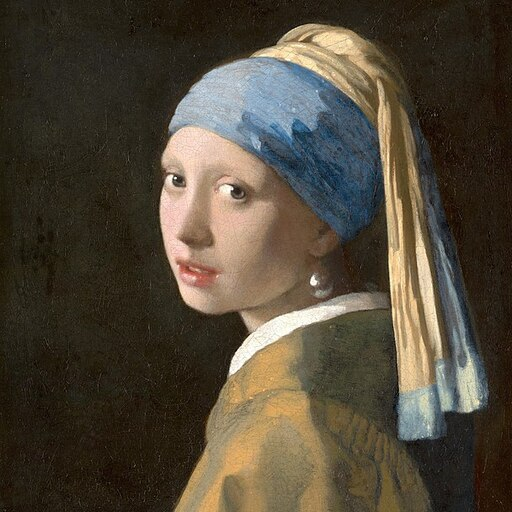

In [11]:
face_image

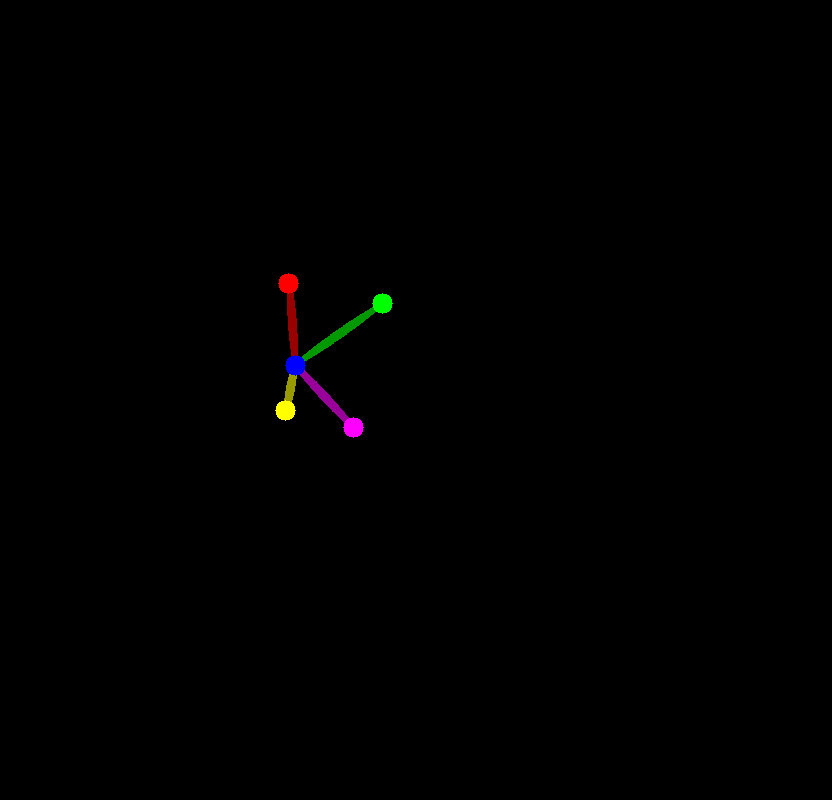

In [12]:
face_kps

## Prepare InstantID pipeline 
[back to top ⬆️](#Table-of-contents:)

The code below downloads InstantID pipeline parts - ControlNet for face pose and IP-Adapter for adding face embeddings to prompt

In [13]:
from huggingface_hub import hf_hub_download

hf_hub_download(
    repo_id="InstantX/InstantID",
    filename="ControlNetModel/config.json",
    local_dir="./checkpoints",
)
hf_hub_download(
    repo_id="InstantX/InstantID",
    filename="ControlNetModel/diffusion_pytorch_model.safetensors",
    local_dir="./checkpoints",
)
hf_hub_download(repo_id="InstantX/InstantID", filename="ip-adapter.bin", local_dir="./checkpoints");

As it was discussed in model description, InstantID does not required diffusion model fine-tuning and can be applied on existing Stable Diffusion pipeline. We will use [`stable-diffusion-xl-bas-1-0`](https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0) as basic text-to-image diffusion pipeline. We also apply [LCM LoRA](https://huggingface.co/latent-consistency/lcm-lora-sdxl) to speedup the generation process. Previously, we already considered how to convert and run SDXL model for Text-to-Image and Image-to-Image generation using Optimum-Intel library (please check out this notebook for [details](../stable-diffusion-xl/stable-diffusion-xl.ipynb)), now we will use it in combination with ControlNet and convert it using OpenVINO Model Conversion API. 

In [14]:
from diffusers.models import ControlNetModel
from diffusers import LCMScheduler
from pipeline_stable_diffusion_xl_instantid import StableDiffusionXLInstantIDPipeline

import torch
from PIL import Image
import gc


ov_controlnet_path = MODELS_DIR / "controlnet.xml"
ov_unet_path = MODELS_DIR / "unet.xml"
ov_vae_decoder_path = MODELS_DIR / "vae_decoder.xml"
ov_text_encoder_path = MODELS_DIR / "text_encoder.xml"
ov_text_encoder_2_path = MODELS_DIR / "text_encoder_2.xml"
ov_image_proj_encoder_path = MODELS_DIR / "image_proj_model.xml"

required_pipeline_parts = [
    ov_controlnet_path,
    ov_unet_path,
    ov_vae_decoder_path,
    ov_text_encoder_path,
    ov_text_encoder_2_path,
    ov_image_proj_encoder_path,
]


def load_pytorch_pipeline(sdxl_id="stabilityai/stable-diffusion-xl-base-1.0"):
    # prepare models under ./checkpoints
    face_adapter = Path("checkpoints/ip-adapter.bin")
    controlnet_path = Path("checkpoints/ControlNetModel")

    # load IdentityNet
    controlnet = ControlNetModel.from_pretrained(controlnet_path)

    pipe = StableDiffusionXLInstantIDPipeline.from_pretrained(sdxl_id, controlnet=controlnet)

    # load adapter
    pipe.load_ip_adapter_instantid(face_adapter)
    # load lcm lora
    pipe.load_lora_weights("latent-consistency/lcm-lora-sdxl")
    pipe.fuse_lora()
    scheduler = LCMScheduler.from_config(pipe.scheduler.config)
    pipe.set_ip_adapter_scale(0.8)

    controlnet, unet, vae = pipe.controlnet, pipe.unet, pipe.vae
    text_encoder, text_encoder_2, tokenizer, tokenizer_2 = (
        pipe.text_encoder,
        pipe.text_encoder_2,
        pipe.tokenizer,
        pipe.tokenizer_2,
    )
    image_proj_model = pipe.image_proj_model
    return (
        controlnet,
        unet,
        vae,
        text_encoder,
        text_encoder_2,
        tokenizer,
        tokenizer_2,
        image_proj_model,
        scheduler,
    )


load_torch_models = any([not path.exists() for path in required_pipeline_parts])

if load_torch_models:
    (
        controlnet,
        unet,
        vae,
        text_encoder,
        text_encoder_2,
        tokenizer,
        tokenizer_2,
        image_proj_model,
        scheduler,
    ) = load_pytorch_pipeline()
    tokenizer.save_pretrained(MODELS_DIR / "tokenizer")
    tokenizer_2.save_pretrained(MODELS_DIR / "tokenizer_2")
    scheduler.save_pretrained(MODELS_DIR / "scheduler")
else:
    (
        controlnet,
        unet,
        vae,
        text_encoder,
        text_encoder_2,
        tokenizer,
        tokenizer_2,
        image_proj_model,
        scheduler,
    ) = (None, None, None, None, None, None, None, None, None)

gc.collect();

## Convert InstantID pipeline components to OpenVINO Intermediate Representation format
[back to top ⬆️](#Table-of-contents:)

Starting from 2023.0 release, OpenVINO supports PyTorch models conversion directly. We need to provide a model object, input data for model tracing to `ov.convert_model` function to obtain OpenVINO `ov.Model` object instance. Model can be saved on disk for next deployment using `ov.save_model` function.

The pipeline consists of the following list of important parts:

* Image Projection model for getting image prompt embeddings. It is similar with IP-Adapter approach described in [this tutorial](../stable-diffusion-ip-adapter/stable-diffusion-ip-adapter.ipynb), but instead of image, it uses face embeddings as input for image prompt encoding.
* Text Encoders for creating text embeddings to generate an image from a text prompt.
* ControlNet for conditioning by face keypoints image for translation face pose on generated image.
* Unet for step-by-step denoising latent image representation.
* Autoencoder (VAE) for decoding latent space to image.


### ControlNet
[back to top ⬆️](#Table-of-contents:)

ControlNet was introduced in [Adding Conditional Control to Text-to-Image Diffusion Models](https://arxiv.org/abs/2302.05543) paper. It provides a framework that enables support for various spatial contexts such as a depth map, a segmentation map, a scribble, and key points that can serve as additional conditionings to Diffusion models such as Stable Diffusion. In this [tutorial](../controlnet-stable-diffusion/controlnet-stable-diffusion.ipynb) we already considered how to convert and use ControlNet with Stable Diffusion pipeline. The process of usage ControlNet for Stable Diffusion XL remains without changes.

In [15]:
import openvino as ov
from functools import partial


def cleanup_torchscript_cache():
    """
    Helper for removing cached model representation
    """
    torch._C._jit_clear_class_registry()
    torch.jit._recursive.concrete_type_store = torch.jit._recursive.ConcreteTypeStore()
    torch.jit._state._clear_class_state()


controlnet_example_input = {
    "sample": torch.ones((2, 4, 100, 100)),
    "timestep": torch.tensor(1, dtype=torch.float32),
    "encoder_hidden_states": torch.randn((2, 77, 2048)),
    "controlnet_cond": torch.randn((2, 3, 800, 800)),
    "conditioning_scale": torch.tensor(0.8, dtype=torch.float32),
    "added_cond_kwargs": {
        "text_embeds": torch.zeros((2, 1280)),
        "time_ids": torch.ones((2, 6), dtype=torch.int32),
    },
}


if not ov_controlnet_path.exists():
    controlnet.forward = partial(controlnet.forward, return_dict=False)
    with torch.no_grad():
        ov_controlnet = ov.convert_model(controlnet, example_input=controlnet_example_input)
    ov_controlnet.inputs[-1].get_node().set_element_type(ov.Type.f32)
    ov_controlnet.inputs[-1].get_node().set_partial_shape(ov.PartialShape([-1, 6]))
    ov_controlnet.validate_nodes_and_infer_types()
    ov.save_model(ov_controlnet, ov_controlnet_path)
    cleanup_torchscript_cache()
    del ov_controlnet
    gc.collect()

if not ov_unet_path.exists():
    out = controlnet(**controlnet_example_input)
    down_block_res_samples, mid_block_res_sample = out[0], out[1]
else:
    down_block_res_samples, mid_block_res_sample = None, None

del controlnet
gc.collect();

### Unet
[back to top ⬆️](#Table-of-contents:)

Compared with Stable Diffusion, Stable Diffusion XL Unet has an additional input for the `time_ids` condition. As we use ControlNet and Image Projection Model, these models' outputs also contribute to preparing model input for Unet.

In [16]:
from typing import Tuple


class UnetWrapper(torch.nn.Module):
    def __init__(
        self,
        unet,
        sample_dtype=torch.float32,
        timestep_dtype=torch.int64,
        encoder_hidden_states_dtype=torch.float32,
        down_block_additional_residuals_dtype=torch.float32,
        mid_block_additional_residual_dtype=torch.float32,
        text_embeds_dtype=torch.float32,
        time_ids_dtype=torch.int32,
    ):
        super().__init__()
        self.unet = unet
        self.sample_dtype = sample_dtype
        self.timestep_dtype = timestep_dtype
        self.encoder_hidden_states_dtype = encoder_hidden_states_dtype
        self.down_block_additional_residuals_dtype = down_block_additional_residuals_dtype
        self.mid_block_additional_residual_dtype = mid_block_additional_residual_dtype
        self.text_embeds_dtype = text_embeds_dtype
        self.time_ids_dtype = time_ids_dtype

    def forward(
        self,
        sample: torch.Tensor,
        timestep: torch.Tensor,
        encoder_hidden_states: torch.Tensor,
        down_block_additional_residuals: Tuple[torch.Tensor],
        mid_block_additional_residual: torch.Tensor,
        text_embeds: torch.Tensor,
        time_ids: torch.Tensor,
    ):
        sample.to(self.sample_dtype)
        timestep.to(self.timestep_dtype)
        encoder_hidden_states.to(self.encoder_hidden_states_dtype)
        down_block_additional_residuals = [res.to(self.down_block_additional_residuals_dtype) for res in down_block_additional_residuals]
        mid_block_additional_residual.to(self.mid_block_additional_residual_dtype)
        added_cond_kwargs = {
            "text_embeds": text_embeds.to(self.text_embeds_dtype),
            "time_ids": time_ids.to(self.time_ids_dtype),
        }

        return self.unet(
            sample,
            timestep,
            encoder_hidden_states,
            down_block_additional_residuals=down_block_additional_residuals,
            mid_block_additional_residual=mid_block_additional_residual,
            added_cond_kwargs=added_cond_kwargs,
        )


if not ov_unet_path.exists():
    unet_example_input = {
        "sample": torch.ones((2, 4, 100, 100)),
        "timestep": torch.tensor(1, dtype=torch.float32),
        "encoder_hidden_states": torch.randn((2, 77, 2048)),
        "down_block_additional_residuals": down_block_res_samples,
        "mid_block_additional_residual": mid_block_res_sample,
        "text_embeds": torch.zeros((2, 1280)),
        "time_ids": torch.ones((2, 6), dtype=torch.int32),
    }
    unet = UnetWrapper(unet)
    with torch.no_grad():
        ov_unet = ov.convert_model(unet, example_input=unet_example_input)
    for i in range(3, len(ov_unet.inputs) - 2):
        ov_unet.inputs[i].get_node().set_element_type(ov.Type.f32)

    ov_unet.validate_nodes_and_infer_types()
    ov.save_model(ov_unet, ov_unet_path)
    del ov_unet
    cleanup_torchscript_cache()
    gc.collect()

del unet
gc.collect();

### VAE Decoder
[back to top ⬆️](#Table-of-contents:)

The VAE model has two parts, an encoder and a decoder. The encoder is used to convert the image into a low dimensional latent representation, which will serve as the input to the U-Net model. The decoder, conversely, transforms the latent representation back into an image.
For InstantID pipeline we will use VAE only for decoding Unet generated image, it means that we can skip VAE encoder part conversion. 

In [17]:
class VAEDecoderWrapper(torch.nn.Module):
    def __init__(self, vae_decoder):
        super().__init__()
        self.vae = vae_decoder

    def forward(self, latents):
        return self.vae.decode(latents)


if not ov_vae_decoder_path.exists():
    vae_decoder = VAEDecoderWrapper(vae)

    with torch.no_grad():
        ov_vae_decoder = ov.convert_model(vae_decoder, example_input=torch.zeros((1, 4, 64, 64)))
    ov.save_model(ov_vae_decoder, ov_vae_decoder_path)
    del ov_vae_decoder
    cleanup_torchscript_cache()
    del vae_decoder
    gc.collect()

del vae
gc.collect();

### Text Encoders
[back to top ⬆️](#Table-of-contents:)

The text-encoder is responsible for transforming the input prompt, for example, "a photo of an astronaut riding a horse" into an embedding space that can be understood by the U-Net. It is usually a simple transformer-based encoder that maps a sequence of input tokens to a sequence of latent text embeddings.

In [18]:
import types

inputs = {"input_ids": torch.ones((1, 77), dtype=torch.long)}

if not ov_text_encoder_path.exists():
    text_encoder.eval()
    text_encoder.config.output_hidden_states = True
    text_encoder.config.return_dict = False
    with torch.no_grad():
        ov_text_encoder = ov.convert_model(text_encoder, example_input=inputs)
    ov.save_model(ov_text_encoder, ov_text_encoder_path)
    del ov_text_encoder
    cleanup_torchscript_cache()
    gc.collect()

del text_encoder
gc.collect()


def text_encoder_fwd_wrapper(self, input_ids):
    res = self._orig_forward(input_ids, return_dict=True, output_hidden_states=True)
    return tuple([v for v in res.values() if v is not None])


if not ov_text_encoder_2_path.exists():
    text_encoder_2.eval()
    text_encoder_2._orig_forward = text_encoder_2.forward
    text_encoder_2.forward = types.MethodType(text_encoder_fwd_wrapper, text_encoder_2)

    with torch.no_grad():
        ov_text_encoder = ov.convert_model(text_encoder_2, example_input=inputs)
    ov.save_model(ov_text_encoder, ov_text_encoder_2_path)
    del ov_text_encoder
    cleanup_torchscript_cache()
del text_encoder_2
gc.collect();

### Image Projection Model
[back to top ⬆️](#Table-of-contents:)

Image projection model is responsible to transforming face embeddings to image prompt embeddings

In [19]:
if not ov_image_proj_encoder_path.exists():
    with torch.no_grad():
        ov_image_encoder = ov.convert_model(image_proj_model, example_input=torch.zeros((2, 1, 512)))
    ov.save_model(ov_image_encoder, ov_image_proj_encoder_path)
    del ov_image_encoder
    cleanup_torchscript_cache()
del image_proj_model
gc.collect();

## Prepare OpenVINO InstantID Pipeline
[back to top ⬆️](#Table-of-contents:)

In [20]:
import numpy as np
from diffusers import StableDiffusionXLControlNetPipeline
from diffusers.pipelines.stable_diffusion_xl import StableDiffusionXLPipelineOutput
from typing import Any, Callable, Optional, Union

import torch

from diffusers.image_processor import PipelineImageInput, VaeImageProcessor


class OVStableDiffusionXLInstantIDPipeline(StableDiffusionXLControlNetPipeline):
    def __init__(
        self,
        text_encoder,
        text_encoder_2,
        image_proj_model,
        controlnet,
        unet,
        vae_decoder,
        tokenizer,
        tokenizer_2,
        scheduler,
    ):
        self.text_encoder = text_encoder
        self.text_encoder_2 = text_encoder_2
        self.tokenizer = tokenizer
        self.tokenizer_2 = tokenizer_2
        self.image_proj_model = image_proj_model
        self.controlnet = controlnet
        self.unet = unet
        self.vae_decoder = vae_decoder
        self.scheduler = scheduler
        self.image_proj_model_in_features = 512
        self.vae_scale_factor = 8
        self.vae_scaling_factor = 0.13025
        self.image_processor = VaeImageProcessor(vae_scale_factor=self.vae_scale_factor, do_convert_rgb=True)
        self.control_image_processor = VaeImageProcessor(
            vae_scale_factor=self.vae_scale_factor,
            do_convert_rgb=True,
            do_normalize=False,
        )
        self._internal_dict = {}
        self._progress_bar_config = {}

    def _encode_prompt_image_emb(self, prompt_image_emb, num_images_per_prompt, do_classifier_free_guidance):
        if isinstance(prompt_image_emb, torch.Tensor):
            prompt_image_emb = prompt_image_emb.clone().detach()
        else:
            prompt_image_emb = torch.tensor(prompt_image_emb)

        prompt_image_emb = prompt_image_emb.reshape([1, -1, self.image_proj_model_in_features])

        if do_classifier_free_guidance:
            prompt_image_emb = torch.cat([torch.zeros_like(prompt_image_emb), prompt_image_emb], dim=0)
        else:
            prompt_image_emb = torch.cat([prompt_image_emb], dim=0)
        prompt_image_emb = self.image_proj_model(prompt_image_emb)[0]

        bs_embed, seq_len, _ = prompt_image_emb.shape
        prompt_image_emb = np.tile(prompt_image_emb, (1, num_images_per_prompt, 1))
        prompt_image_emb = prompt_image_emb.reshape(bs_embed * num_images_per_prompt, seq_len, -1)

        return prompt_image_emb

    def __call__(
        self,
        prompt: Union[str, list[str]] = None,
        prompt_2: Optional[Union[str, list[str]]] = None,
        image: PipelineImageInput = None,
        height: Optional[int] = None,
        width: Optional[int] = None,
        num_inference_steps: int = 50,
        guidance_scale: float = 5.0,
        negative_prompt: Optional[Union[str, list[str]]] = None,
        negative_prompt_2: Optional[Union[str, list[str]]] = None,
        num_images_per_prompt: Optional[int] = 1,
        eta: float = 0.0,
        generator: Optional[Union[torch.Generator, list[torch.Generator]]] = None,
        latents: Optional[torch.FloatTensor] = None,
        prompt_embeds: Optional[torch.FloatTensor] = None,
        negative_prompt_embeds: Optional[torch.FloatTensor] = None,
        pooled_prompt_embeds: Optional[torch.FloatTensor] = None,
        negative_pooled_prompt_embeds: Optional[torch.FloatTensor] = None,
        image_embeds: Optional[torch.FloatTensor] = None,
        output_type: Optional[str] = "pil",
        return_dict: bool = True,
        cross_attention_kwargs: Optional[dict[str, Any]] = None,
        controlnet_conditioning_scale: Union[float, list[float]] = 1.0,
        guess_mode: bool = False,
        control_guidance_start: Union[float, list[float]] = 0.0,
        control_guidance_end: Union[float, list[float]] = 1.0,
        original_size: tuple[int, int] = None,
        crops_coords_top_left: tuple[int, int] = (0, 0),
        target_size: tuple[int, int] = None,
        negative_original_size: Optional[tuple[int, int]] = None,
        negative_crops_coords_top_left: tuple[int, int] = (0, 0),
        negative_target_size: Optional[tuple[int, int]] = None,
        clip_skip: Optional[int] = None,
        callback_on_step_end: Optional[Callable[[int, int, dict], None]] = None,
        callback_on_step_end_tensor_inputs: list[str] = ["latents"],
        # IP adapter
        ip_adapter_scale=None,
        **kwargs,
    ):
        r"""
        The call function to the pipeline for generation.

        Args:
            prompt (`str` or `List[str]`, *optional*):
                The prompt or prompts to guide image generation. If not defined, you need to pass `prompt_embeds`.
            prompt_2 (`str` or `List[str]`, *optional*):
                The prompt or prompts to be sent to `tokenizer_2` and `text_encoder_2`. If not defined, `prompt` is
                used in both text-encoders.
            image (`torch.FloatTensor`, `PIL.Image.Image`, `np.ndarray`, `List[torch.FloatTensor]`, `List[PIL.Image.Image]`, `List[np.ndarray]`,:
                    `List[List[torch.FloatTensor]]`, `List[List[np.ndarray]]` or `List[List[PIL.Image.Image]]`):
                The ControlNet input condition to provide guidance to the `unet` for generation. If the type is
                specified as `torch.FloatTensor`, it is passed to ControlNet as is. `PIL.Image.Image` can also be
                accepted as an image. The dimensions of the output image defaults to `image`'s dimensions. If height__module.unet.up_blocks.0.upsamplers.0.conv.base_layer/aten::_convolu
                and/or width are passed, `image` is resized accordingly. If multiple ControlNets are specified in
                `init`, images must be passed as a list such that each element of the list can be correctly batched for
                input to a single ControlNet.
            height (`int`, *optional*, defaults to `self.unet.config.sample_size * self.vae_scale_factor`):
                The height in pixels of the generated image. Anything below 512 pixels won't work well for
                [stabilityai/stable-diffusion-xl-base-1.0](https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0)
                and checkpoints that are not specifically fine-tuned on low resolutions.
            width (`int`, *optional*, defaults to `self.unet.config.sample_size * self.vae_scale_factor`):
                The width in pixels of the generated image. Anything below 512 pixels won't work well for
                [stabilityai/stable-diffusion-xl-base-1.0](https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0)
                and checkpoints that are not specifically fine-tuned on low resolutions.
            num_inference_steps (`int`, *optional*, defaults to 50):
                The number of denoising steps. More denoising steps usually lead to a higher quality image at the
                expense of slower inference.
            guidance_scale (`float`, *optional*, defaults to 5.0):
                A higher guidance scale value encourages the model to generate images closely linked to the text
                `prompt` at the expense of lower image quality. Guidance scale is enabled when `guidance_scale > 1`.
            negative_prompt (`str` or `List[str]`, *optional*):
                The prompt or prompts to guide what to not include in image generation. If not defined, you need to
                pass `negative_prompt_embeds` instead. Ignored when not using guidance (`guidance_scale < 1`).
            negative_prompt_2 (`str` or `List[str]`, *optional*):
                The prompt or prompts to guide what to not include in image generation. This is sent to `tokenizer_2`
                and `text_encoder_2`. If not defined, `negative_prompt` is used in both text-encoders.
            num_images_per_prompt (`int`, *optional*, defaults to 1):
                The number of images to generate per prompt.
            eta (`float`, *optional*, defaults to 0.0):
                Corresponds to parameter eta (η) from the [DDIM](https://arxiv.org/abs/2010.02502) paper. Only applies
                to the [`~schedulers.DDIMScheduler`], and is ignored in other schedulers.
            generator (`torch.Generator` or `List[torch.Generator]`, *optional*):
                A [`torch.Generator`](https://pytorch.org/docs/stable/generated/torch.Generator.html) to make
                generation deterministic.
            latents (`torch.FloatTensor`, *optional*):
                Pre-generated noisy latents sampled from a Gaussian distribution, to be used as inputs for image
                generation. Can be used to tweak the same generation with different prompts. If not provided, a latents
                tensor is generated by sampling using the supplied random `generator`.
            prompt_embeds (`torch.FloatTensor`, *optional*):
                Pre-generated text embeddings. Can be used to easily tweak text inputs (prompt weighting). If not
                provided, text embeddings are generated from the `prompt` input argument.
            negative_prompt_embeds (`torch.FloatTensor`, *optional*):
                Pre-generated negative text embeddings. Can be used to easily tweak text inputs (prompt weighting). If
                not provided, `negative_prompt_embeds` are generated from the `negative_prompt` input argument.
            pooled_prompt_embeds (`torch.FloatTensor`, *optional*):
                Pre-generated pooled text embeddings. Can be used to easily tweak text inputs (prompt weighting). If
                not provided, pooled text embeddings are generated from `prompt` input argument.
            negative_pooled_prompt_embeds (`torch.FloatTensor`, *optional*):
                Pre-generated negative pooled text embeddings. Can be used to easily tweak text inputs (prompt
                weighting). If not provided, pooled `negative_prompt_embeds` are generated from `negative_prompt` input
                argument.
            image_embeds (`torch.FloatTensor`, *optional*):
                Pre-generated image embeddings.
            output_type (`str`, *optional*, defaults to `"pil"`):
                The output format of the generated image. Choose between `PIL.Image` or `np.array`.
            return_dict (`bool`, *optional*, defaults to `True`):
                Whether or not to return a [`~pipelines.stable_diffusion.StableDiffusionPipelineOutput`] instead of a
                plain tuple.
            controlnet_conditioning_scale (`float` or `List[float]`, *optional*, defaults to 1.0):
                The outputs of the ControlNet are multiplied by `controlnet_conditioning_scale` before they are added
                to the residual in the original `unet`. If multiple ControlNets are specified in `init`, you can set
                the corresponding scale as a list.
            control_guidance_start (`float` or `List[float]`, *optional*, defaults to 0.0):
                The percentage of total steps at which the ControlNet starts applying.
            control_guidance_end (`float` or `List[float]`, *optional*, defaults to 1.0):
                The percentage of total steps at which the ControlNet stops applying.
            original_size (`Tuple[int]`, *optional*, defaults to (1024, 1024)):
                If `original_size` is not the same as `target_size` the image will appear to be down- or upsampled.
                `original_size` defaults to `(height, width)` if not specified. Part of SDXL's micro-conditioning as
                explained in section 2.2 of
                [https://huggingface.co/papers/2307.01952](https://huggingface.co/papers/2307.01952).
            crops_coords_top_left (`Tuple[int]`, *optional*, defaults to (0, 0)):
                `crops_coords_top_left` can be used to generate an image that appears to be "cropped" from the position
                `crops_coords_top_left` downwards. Favorable, well-centered images are usually achieved by setting
                `crops_coords_top_left` to (0, 0). Part of SDXL's micro-conditioning as explained in section 2.2 of
                [https://huggingface.co/papers/2307.01952](https://huggingface.co/papers/2307.01952).
            target_size (`Tuple[int]`, *optional*, defaults to (1024, 1024)):
                For most cases, `target_size` should be set to the desired height and width of the generated image. If
                not specified it will default to `(height, width)`. Part of SDXL's micro-conditioning as explained in
                section 2.2 of [https://huggingface.co/papers/2307.01952](https://huggingface.co/papers/2307.01952).
            negative_original_size (`Tuple[int]`, *optional*, defaults to (1024, 1024)):
                To negatively condition the generation process based on a specific image resolution. Part of SDXL's
                micro-conditioning as explained in section 2.2 of
                [https://huggingface.co/papers/2307.01952](https://huggingface.co/papers/2307.01952). For more
                information, refer toencode_pro this issue thread: https://github.com/huggingface/diffusers/issues/4208.
            negative_crops_coords_top_left (`Tuple[int]`, *optional*, defaults to (0, 0)):
                To negatively condition the generation process based on a specific crop coordinates. Part of SDXL's
                micro-conditioning as explained in section 2.2 of
                [https://huggingface.co/papers/2307.01952](https://huggingface.co/papers/2307.01952). For more
                information, refer to this issue thread: https://github.com/huggingface/diffusers/issues/4208.
            negative_target_size (`Tuple[int]`, *optional*, defaults to (1024, 1024)):
                To negatively condition the generation process based on a target image resolution. It should be as same
                as the `target_size` for most cases. Part of SDXL's micro-conditioning as explained in section 2.2 of
                [https://huggingface.co/papers/2307.01952](https://huggingface.co/papers/2307.01952). For more
                information, refer to this issue thread: https://github.com/huggingface/diffusers/issues/4208.
            clip_skip (`int`, *optional*):
                Number of layers to be skipped from CLIP while computing the prompt embeddings. A value of 1 means that
                the output of the pre-final layer will be used for computing the prompt embeddings.

        Examples:

        Returns:
            [`~pipelines.stable_diffusion.StableDiffusionPipelineOutput`] or `tuple`:
                If `return_dict` is `True`, [`~pipelines.stable_diffusion.StableDiffusionPipelineOutput`] is returned,
                otherwise a `tuple` is returned containing the output images.
        """

        do_classifier_free_guidance = guidance_scale >= 1.0
        # align format for control guidance
        if not isinstance(control_guidance_start, list) and isinstance(control_guidance_end, list):
            control_guidance_start = len(control_guidance_end) * [control_guidance_start]
        elif not isinstance(control_guidance_end, list) and isinstance(control_guidance_start, list):
            control_guidance_end = len(control_guidance_start) * [control_guidance_end]
        elif not isinstance(control_guidance_start, list) and not isinstance(control_guidance_end, list):
            control_guidance_start, control_guidance_end = (
                [control_guidance_start],
                [control_guidance_end],
            )

        # 2. Define call parameters
        if prompt is not None and isinstance(prompt, str):
            batch_size = 1
        elif prompt is not None and isinstance(prompt, list):
            batch_size = len(prompt)
        else:
            batch_size = prompt_embeds.shape[0]

        (
            prompt_embeds,
            negative_prompt_embeds,
            pooled_prompt_embeds,
            negative_pooled_prompt_embeds,
        ) = self.encode_prompt(
            prompt,
            prompt_2,
            num_images_per_prompt,
            do_classifier_free_guidance,
            negative_prompt,
            negative_prompt_2,
            prompt_embeds=prompt_embeds,
            negative_prompt_embeds=negative_prompt_embeds,
            pooled_prompt_embeds=pooled_prompt_embeds,
            negative_pooled_prompt_embeds=negative_pooled_prompt_embeds,
            lora_scale=None,
            clip_skip=clip_skip,
        )

        # 3.2 Encode image prompt
        prompt_image_emb = self._encode_prompt_image_emb(image_embeds, num_images_per_prompt, do_classifier_free_guidance)

        # 4. Prepare image
        image = self.prepare_image(
            image=image,
            width=width,
            height=height,
            batch_size=batch_size * num_images_per_prompt,
            num_images_per_prompt=num_images_per_prompt,
            do_classifier_free_guidance=do_classifier_free_guidance,
            guess_mode=guess_mode,
        )
        height, width = image.shape[-2:]

        # 5. Prepare timesteps
        self.scheduler.set_timesteps(num_inference_steps)
        timesteps = self.scheduler.timesteps

        # 6. Prepare latent variables
        num_channels_latents = 4
        latents = self.prepare_latents(
            int(batch_size) * int(num_images_per_prompt),
            int(num_channels_latents),
            int(height),
            int(width),
            dtype=torch.float32,
            device=torch.device("cpu"),
            generator=generator,
            latents=latents,
        )

        # 7. Prepare extra step kwargs.
        extra_step_kwargs = self.prepare_extra_step_kwargs(generator, eta)
        # 7.1 Create tensor stating which controlnets to keep
        controlnet_keep = []
        for i in range(len(timesteps)):
            keeps = [1.0 - float(i / len(timesteps) < s or (i + 1) / len(timesteps) > e) for s, e in zip(control_guidance_start, control_guidance_end)]
            controlnet_keep.append(keeps)

        # 7.2 Prepare added time ids & embeddings
        if isinstance(image, list):
            original_size = original_size or image[0].shape[-2:]
        else:
            original_size = original_size or image.shape[-2:]
        target_size = target_size or (height, width)

        add_text_embeds = pooled_prompt_embeds
        if self.text_encoder_2 is None:
            text_encoder_projection_dim = pooled_prompt_embeds.shape[-1]
        else:
            text_encoder_projection_dim = 1280

        add_time_ids = self._get_add_time_ids(
            original_size,
            crops_coords_top_left,
            target_size,
            text_encoder_projection_dim=text_encoder_projection_dim,
        )

        if negative_original_size is not None and negative_target_size is not None:
            negative_add_time_ids = self._get_add_time_ids(
                negative_original_size,
                negative_crops_coords_top_left,
                negative_target_size,
                text_encoder_projection_dim=text_encoder_projection_dim,
            )
        else:
            negative_add_time_ids = add_time_ids

        if do_classifier_free_guidance:
            prompt_embeds = np.concatenate([negative_prompt_embeds, prompt_embeds], axis=0)
            add_text_embeds = np.concatenate([negative_pooled_prompt_embeds, add_text_embeds], axis=0)
            add_time_ids = np.concatenate([negative_add_time_ids, add_time_ids], axis=0)

        add_time_ids = np.tile(add_time_ids, (batch_size * num_images_per_prompt, 1))
        encoder_hidden_states = np.concatenate([prompt_embeds, prompt_image_emb], axis=1)

        # 8. Denoising loop
        with self.progress_bar(total=num_inference_steps) as progress_bar:
            for i, t in enumerate(timesteps):
                # expand the latents if we are doing classifier free guidance
                latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
                latent_model_input = self.scheduler.scale_model_input(latent_model_input, t)

                # controlnet(s) inference
                control_model_input = latent_model_input

                cond_scale = controlnet_conditioning_scale

                controlnet_outputs = self.controlnet(
                    [
                        control_model_input,
                        t,
                        prompt_image_emb,
                        image,
                        cond_scale,
                        add_text_embeds,
                        add_time_ids,
                    ]
                )

                controlnet_additional_blocks = list(controlnet_outputs.values())

                # predict the noise residual
                noise_pred = self.unet(
                    [
                        latent_model_input,
                        t,
                        encoder_hidden_states,
                        *controlnet_additional_blocks,
                        add_text_embeds,
                        add_time_ids,
                    ]
                )[0]

                # perform guidance
                if do_classifier_free_guidance:
                    noise_pred_uncond, noise_pred_text = noise_pred[0], noise_pred[1]
                    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

                # compute the previous noisy sample x_t -> x_t-1
                latents = self.scheduler.step(
                    torch.from_numpy(noise_pred),
                    t,
                    latents,
                    **extra_step_kwargs,
                    return_dict=False,
                )[0]
                progress_bar.update()

        if not output_type == "latent":
            image = self.vae_decoder(latents / self.vae_scaling_factor)[0]
        else:
            image = latents

        if not output_type == "latent":
            image = self.image_processor.postprocess(torch.from_numpy(image), output_type=output_type)

        if not return_dict:
            return (image,)

        return StableDiffusionXLPipelineOutput(images=image)

    def encode_prompt(
        self,
        prompt: str,
        prompt_2: Optional[str] = None,
        num_images_per_prompt: int = 1,
        do_classifier_free_guidance: bool = True,
        negative_prompt: Optional[str] = None,
        negative_prompt_2: Optional[str] = None,
        prompt_embeds: Optional[torch.FloatTensor] = None,
        negative_prompt_embeds: Optional[torch.FloatTensor] = None,
        pooled_prompt_embeds: Optional[torch.FloatTensor] = None,
        negative_pooled_prompt_embeds: Optional[torch.FloatTensor] = None,
        lora_scale: Optional[float] = None,
        clip_skip: Optional[int] = None,
    ):
        r"""
        Encodes the prompt into text encoder hidden states.

        Args:
            prompt (`str` or `List[str]`, *optional*):
                prompt to be encoded
            prompt_2 (`str` or `List[str]`, *optional*):
                The prompt or prompts to be sent to the `tokenizer_2` and `text_encoder_2`. If not defined, `prompt` is
                used in both text-encoders
            num_images_per_prompt (`int`):
                number of images that should be generated per prompt
            do_classifier_free_guidance (`bool`):
                whether to use classifier free guidance or not
            negative_prompt (`str` or `List[str]`, *optional*):
                The prompt or prompts not to guide the image generation. If not defined, one has to pass
                `negative_prompt_embeds` instead. Ignored when not using guidance (i.e., ignored if `guidance_scale` is
                less than `1`).
            negative_prompt_2 (`str` or `List[str]`, *optional*):
                The prompt or prompts not to guide the image generation to be sent to `tokenizer_2` and
                `text_encoder_2`. If not defined, `negative_prompt` is used in both text-encoders
            prompt_embeds (`torch.FloatTensor`, *optional*):
                Pre-generated text embeddings. Can be used to easily tweak text inputs, *e.g.* prompt weighting. If not
                provided, text embeddings will be generated from `prompt` input argument.
            negative_prompt_embeds (`torch.FloatTensor`, *optional*):
                Pre-generated negative text embeddings. Can be used to easily tweak text inputs, *e.g.* prompt
                weighting. If not provided, negative_prompt_embeds will be generated from `negative_prompt` input
                argument.
            pooled_prompt_embeds (`torch.FloatTensor`, *optional*):
                Pre-generated pooled text embeddings. Can be used to easily tweak text inputs, *e.g.* prompt weighting.
                If not provided, pooled text embeddings will be generated from `prompt` input argument.
            negative_pooled_prompt_embeds (`torch.FloatTensor`, *optional*):
                Pre-generated negative pooled text embeddings. Can be used to easily tweak text inputs, *e.g.* prompt
                weighting. If not provided, pooled negative_prompt_embeds will be generated from `negative_prompt`
                input argument.
            lora_scale (`float`, *optional*):
                A lora scale that will be applied to all LoRA layers of the text encoder if LoRA layers are loaded.
            clip_skip (`int`, *optional*):
                Number of layers to be skipped from CLIP while computing the prompt embeddings. A value of 1 means that
                the output of the pre-final layer will be used for computing the prompt embeddings.
        """
        prompt = [prompt] if isinstance(prompt, str) else prompt

        if prompt is not None:
            batch_size = len(prompt)
        else:
            batch_size = prompt_embeds.shape[0]

        # Define tokenizers and text encoders
        tokenizers = [self.tokenizer, self.tokenizer_2] if self.tokenizer is not None else [self.tokenizer_2]
        text_encoders = [self.text_encoder, self.text_encoder_2] if self.text_encoder is not None else [self.text_encoder_2]

        if prompt_embeds is None:
            prompt_2 = prompt_2 or prompt
            prompt_2 = [prompt_2] if isinstance(prompt_2, str) else prompt_2

            # textual inversion: procecss multi-vector tokens if necessary
            prompt_embeds_list = []
            prompts = [prompt, prompt_2]
            for prompt, tokenizer, text_encoder in zip(prompts, tokenizers, text_encoders):
                text_inputs = tokenizer(
                    prompt,
                    padding="max_length",
                    max_length=tokenizer.model_max_length,
                    truncation=True,
                    return_tensors="pt",
                )

                text_input_ids = text_inputs.input_ids

                prompt_embeds = text_encoder(text_input_ids)

                # We are only ALWAYS interested in the pooled output of the final text encoder
                pooled_prompt_embeds = prompt_embeds[0]
                hidden_states = list(prompt_embeds.values())[1:]
                if clip_skip is None:
                    prompt_embeds = hidden_states[-2]
                else:
                    # "2" because SDXL always indexes from the penultimate layer.
                    prompt_embeds = hidden_states[-(clip_skip + 2)]

                prompt_embeds_list.append(prompt_embeds)

            prompt_embeds = np.concatenate(prompt_embeds_list, axis=-1)

        # get unconditional embeddings for classifier free guidance
        zero_out_negative_prompt = negative_prompt is None
        if do_classifier_free_guidance and negative_prompt_embeds is None and zero_out_negative_prompt:
            negative_prompt_embeds = np.zeros_like(prompt_embeds)
            negative_pooled_prompt_embeds = np.zeros_like(pooled_prompt_embeds)
        elif do_classifier_free_guidance and negative_prompt_embeds is None:
            negative_prompt = negative_prompt or ""
            negative_prompt_2 = negative_prompt_2 or negative_prompt

            # normalize str to list
            negative_prompt = batch_size * [negative_prompt] if isinstance(negative_prompt, str) else negative_prompt
            negative_prompt_2 = batch_size * [negative_prompt_2] if isinstance(negative_prompt_2, str) else negative_prompt_2

            uncond_tokens: list[str]
            if prompt is not None and type(prompt) is not type(negative_prompt):
                raise TypeError(f"`negative_prompt` should be the same type to `prompt`, but got {type(negative_prompt)} !=" f" {type(prompt)}.")
            elif batch_size != len(negative_prompt):
                raise ValueError(
                    f"`negative_prompt`: {negative_prompt} has batch size {len(negative_prompt)}, but `prompt`:"
                    f" {prompt} has batch size {batch_size}. Please make sure that passed `negative_prompt` matches"
                    " the batch size of `prompt`."
                )
            else:
                uncond_tokens = [negative_prompt, negative_prompt_2]

            negative_prompt_embeds_list = []
            for negative_prompt, tokenizer, text_encoder in zip(uncond_tokens, tokenizers, text_encoders):
                max_length = prompt_embeds.shape[1]
                uncond_input = tokenizer(
                    negative_prompt,
                    padding="max_length",
                    max_length=max_length,
                    truncation=True,
                    return_tensors="pt",
                )

                negative_prompt_embeds = text_encoder(uncond_input.input_ids)
                # We are only ALWAYS interested in the pooled output of the final text encoder
                negative_pooled_prompt_embeds = negative_prompt_embeds[0]
                hidden_states = list(negative_prompt_embeds.values())[1:]
                negative_prompt_embeds = hidden_states[-2]

                negative_prompt_embeds_list.append(negative_prompt_embeds)

            negative_prompt_embeds = np.concatenate(negative_prompt_embeds_list, axis=-1)

        bs_embed, seq_len, _ = prompt_embeds.shape
        # duplicate text embeddings for each generation per prompt, using mps friendly method
        prompt_embeds = np.tile(prompt_embeds, (1, num_images_per_prompt, 1))
        prompt_embeds = prompt_embeds.reshape(bs_embed * num_images_per_prompt, seq_len, -1)

        if do_classifier_free_guidance:
            # duplicate unconditional embeddings for each generation per prompt, using mps friendly method
            seq_len = negative_prompt_embeds.shape[1]
            negative_prompt_embeds = np.tile(negative_prompt_embeds, (1, num_images_per_prompt, 1))
            negative_prompt_embeds = negative_prompt_embeds.reshape(batch_size * num_images_per_prompt, seq_len, -1)

        pooled_prompt_embeds = np.tile(pooled_prompt_embeds, (1, num_images_per_prompt)).reshape(bs_embed * num_images_per_prompt, -1)
        if do_classifier_free_guidance:
            negative_pooled_prompt_embeds = np.tile(negative_pooled_prompt_embeds, (1, num_images_per_prompt)).reshape(bs_embed * num_images_per_prompt, -1)

        return (
            prompt_embeds,
            negative_prompt_embeds,
            pooled_prompt_embeds,
            negative_pooled_prompt_embeds,
        )

    def prepare_image(
        self,
        image,
        width,
        height,
        batch_size,
        num_images_per_prompt,
        do_classifier_free_guidance=False,
        guess_mode=False,
    ):
        image = self.control_image_processor.preprocess(image, height=height, width=width).to(dtype=torch.float32)
        image_batch_size = image.shape[0]

        if image_batch_size == 1:
            repeat_by = batch_size
        else:
            # image batch size is the same as prompt batch size
            repeat_by = num_images_per_prompt

        image = image.repeat_interleave(repeat_by, dim=0)

        if do_classifier_free_guidance and not guess_mode:
            image = torch.cat([image] * 2)

        return image

    def _get_add_time_ids(
        self,
        original_size,
        crops_coords_top_left,
        target_size,
        text_encoder_projection_dim,
    ):
        add_time_ids = list(original_size + crops_coords_top_left + target_size)
        add_time_ids = torch.tensor([add_time_ids])
        return add_time_ids

## Run OpenVINO pipeline inference
[back to top ⬆️](#Table-of-contents:)

### Select inference device for InstantID
[back to top ⬆️](#Table-of-contents:)

In [21]:
device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

### Create pipeline
[back to top ⬆️](#Table-of-contents:)

In [24]:
from transformers import AutoTokenizer


def create_ov_pipe(
    text_encoder_path,
    text_encoder_2_path,
    image_proj_encoder_path,
    controlnet_path,
    unet_path,
    vae_decoder_path,
    tokenizer_path,
    tokenizer_2_path,
    scheduler_path,
):
    return OVStableDiffusionXLInstantIDPipeline(
        core.compile_model(text_encoder_path, device.value),
        core.compile_model(text_encoder_2_path, device.value),
        core.compile_model(image_proj_encoder_path, device.value),
        core.compile_model(controlnet_path, device.value),
        core.compile_model(unet_path, device.value),
        core.compile_model(vae_decoder_path, device.value),
        AutoTokenizer.from_pretrained(tokenizer_path),
        AutoTokenizer.from_pretrained(tokenizer_2_path),
        LCMScheduler.from_pretrained(scheduler_path),
    )


ov_pipe = create_ov_pipe(
    ov_text_encoder_path,
    ov_text_encoder_2_path,
    ov_image_proj_encoder_path,
    ov_controlnet_path,
    ov_unet_path,
    ov_vae_decoder_path,
    MODELS_DIR / "tokenizer",
    MODELS_DIR / "tokenizer_2",
    MODELS_DIR / "scheduler",
)

### Run inference
[back to top ⬆️](#Table-of-contents:)

In [25]:
prompt = "Anime girl"
negative_prompt = ""

image = ov_pipe(
    prompt,
    image_embeds=face_emb,
    image=face_kps,
    num_inference_steps=4,
    negative_prompt=negative_prompt,
    guidance_scale=0.5,
    generator=torch.Generator(device="cpu").manual_seed(1749781188),
).images[0]

  0%|          | 0/4 [00:00<?, ?it/s]

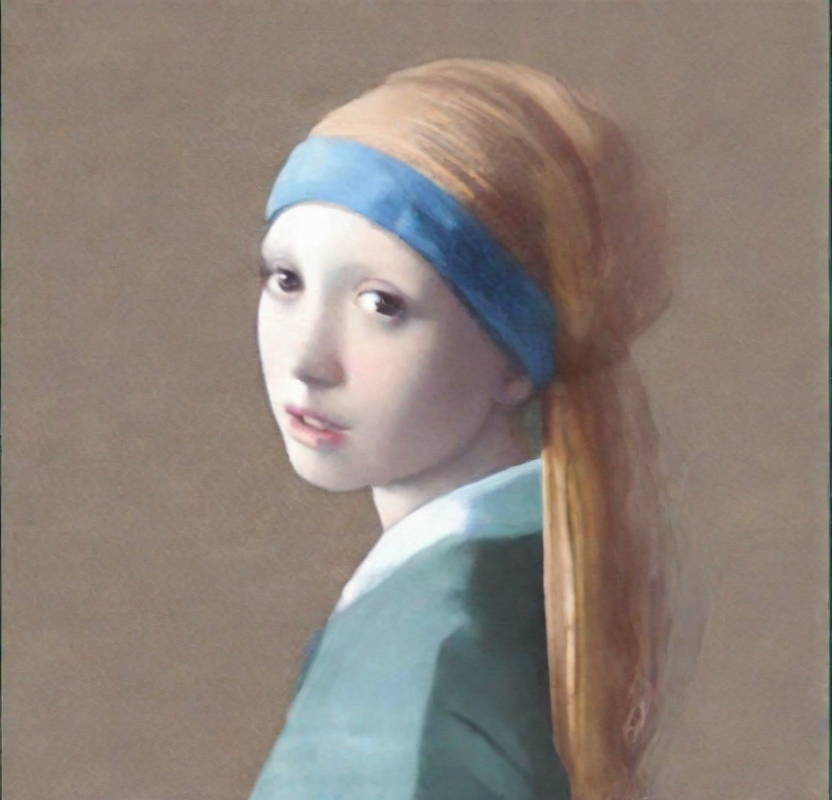

In [26]:
image

## Quantization
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf/) enables post-training quantization by adding quantization layers into model graph and then using a subset of the training dataset to initialize the parameters of these additional quantization layers. Quantized operations are executed in `INT8` instead of `FP32`/`FP16` making model inference faster.

According to `OVStableDiffusionXLInstantIDPipeline` structure, ControlNet and UNet models are used in the cycle repeating inference on each diffusion step, while other parts of pipeline take part only once. Now we will show you how to optimize pipeline using [NNCF](https://github.com/openvinotoolkit/nncf/) to reduce memory and computation cost.

Please select below whether you would like to run quantization to improve model inference speed.

> **NOTE**: Quantization is time and memory consuming operation. Running quantization code below may take some time.

In [27]:
from notebook_utils import quantization_widget

skip_for_device = "GPU" in device.value or (device.value == "AUTO" and any("GPU" in device_name for device_name in core.available_devices))
to_quantize = quantization_widget(not skip_for_device)
to_quantize

Checkbox(value=True, description='Quantization')

Let's load `skip magic` extension to skip quantization if `to_quantize` is not selected

In [28]:
# Fetch `skip_kernel_extension` module
import requests

r = requests.get(
    url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
)
open("skip_kernel_extension.py", "w").write(r.text)

int8_pipe = None

%load_ext skip_kernel_extension

### Prepare calibration datasets
[back to top ⬆️](#Table-of-contents:)

We use a portion of [`wider_face`](https://huggingface.co/datasets/wider_face) dataset from Hugging Face as calibration data. We use prompts below to guide image generation and to determine what not to include in the resulting image.

In [29]:
%%skip not $to_quantize.value

negative_prompts = [
    "blurry unreal occluded",
    "low contrast disfigured uncentered mangled",
    "amateur out of frame low quality nsfw",
    "ugly underexposed jpeg artifacts",
    "low saturation disturbing content",
    "overexposed severe distortion",
    "amateur NSFW",
    "ugly mutilated out of frame disfigured",
]
prompts = [
    "a Naruto-style image of a young boy, incorporating dynamic action lines, intense energy effects, and a sense of movement and power",
    "an anime-style girl, with vibrant, otherworldly colors, fantastical elements, and a sense of awe",
    "analog film photo of a man. faded film, desaturated, 35mm photo, grainy, vignette, vintage, Kodachrome, Lomography, stained, highly detailed, found footage, masterpiece, best quality",
    "Apply a staining filter to give the impression of aged, worn-out film while maintaining sharp detail on a portrait of a woman",
    "a modern picture of a boy an antique feel through selective desaturation, grain addition, and a warm tone, mimicking the style of old photographs",
    "a dreamy, ethereal portrait of a young girl, featuring soft, pastel colors, a blurred background, and a touch of bokeh",
    "a dynamic, action-packed image of a boy in motion, using motion blur, panning, and other techniques to convey a sense of speed and energy",
    "a dramatic, cinematic image of a boy, using color grading, contrast adjustments, and a widescreen aspect ratio, to create a sense of epic scale and grandeur",
    "a portrait of a woman in the style of Picasso's cubism, featuring fragmented shapes, bold lines, and a vibrant color palette",
    "an artwork in the style of Picasso's Blue Period, featuring a somber, melancholic portrait of a person, with muted colors, elongated forms, and a sense of introspection and contemplation",
]

In [30]:
%%skip not $to_quantize.value

import datasets

num_inference_steps = 4
subset_size = 200

ov_int8_unet_path = MODELS_DIR / 'unet_optimized.xml'
ov_int8_controlnet_path = MODELS_DIR / 'controlnet_optimized.xml'

num_samples = int(np.ceil(subset_size / num_inference_steps))
dataset = datasets.load_dataset("wider_face", split="train", streaming=True, trust_remote_code=True).shuffle(seed=42)
face_info = []
for batch in dataset:
    try:
        face_info.append(get_face_info(batch["image"]))
    except RuntimeError:
        continue
    if len(face_info) > num_samples:
        break


To collect intermediate model inputs for calibration we should customize `CompiledModel`.

In [31]:
%%skip not $to_quantize.value

from tqdm.notebook import tqdm
from transformers import set_seed

set_seed(42)

class CompiledModelDecorator(ov.CompiledModel):
    def __init__(self, compiled_model: ov.CompiledModel, keep_prob: float = 1.0):
        super().__init__(compiled_model)
        self.data_cache = []
        self.keep_prob = np.clip(keep_prob, 0, 1)

    def __call__(self, *args, **kwargs):
        if np.random.rand() <= self.keep_prob:
            self.data_cache.append(*args)
        return super().__call__(*args, **kwargs)


def collect_calibration_data(pipeline, face_info, subset_size):
    original_unet = pipeline.unet
    pipeline.unet = CompiledModelDecorator(original_unet)
    pipeline.set_progress_bar_config(disable=True)

    pbar = tqdm(total=subset_size)
    for face_emb, face_kps in face_info:
        negative_prompt = np.random.choice(negative_prompts)
        prompt = np.random.choice(prompts)
        _ = pipeline(
            prompt,
            image_embeds=face_emb,
            image=face_kps,
            num_inference_steps=num_inference_steps,
            negative_prompt=negative_prompt,
            guidance_scale=0.5,
            generator=torch.Generator(device="cpu").manual_seed(1749781188)
        )
        collected_subset_size = len(pipeline.unet.data_cache)
        pbar.update(collected_subset_size - pbar.n)

    calibration_dataset = pipeline.unet.data_cache[:subset_size]
    pipeline.set_progress_bar_config(disable=False)
    pipeline.unet = original_unet
    return calibration_dataset


In [32]:
%%skip not $to_quantize.value

if not (ov_int8_unet_path.exists() and ov_int8_controlnet_path.exists()):
    unet_calibration_data = collect_calibration_data(ov_pipe, face_info, subset_size=subset_size)

  0%|          | 0/200 [00:00<?, ?it/s]

In [33]:
%%skip not $to_quantize.value

def prepare_controlnet_dataset(pipeline, face_info, unet_calibration_data):
    controlnet_calibration_data = []
    i = 0
    for face_emb, face_kps in face_info:
        prompt_image_emb = pipeline._encode_prompt_image_emb(
            face_emb, num_images_per_prompt=1, do_classifier_free_guidance=False
        )
        image = pipeline.prepare_image(
            image=face_kps,
            width=None,
            height=None,
            batch_size=1,
            num_images_per_prompt=1,
            do_classifier_free_guidance=False,
            guess_mode=False,
        )
        for data in unet_calibration_data[i:i+num_inference_steps]:
            controlnet_inputs = [data[0], data[1], prompt_image_emb, image, 1.0, data[-2], data[-1]]
            controlnet_calibration_data.append(controlnet_inputs)
        i += num_inference_steps
    return controlnet_calibration_data


In [34]:
%%skip not $to_quantize.value

if not ov_int8_controlnet_path.exists():
    controlnet_calibration_data = prepare_controlnet_dataset(ov_pipe, face_info, unet_calibration_data)

### Run Quantization
[back to top ⬆️](#Table-of-contents:)

#### Run ControlNet Quantization
[back to top ⬆️](#Table-of-contents:)

Quantization of the first `Convolution` layer impacts the generation results. We recommend using `IgnoredScope` to keep accuracy sensitive layers in FP16 precision.

In [ ]:
%%skip not $to_quantize.value

# Delete loaded full precision pipeline before quantization to lower peak memory footprint.
ov_pipe = None
gc.collect()

In [35]:
%%skip not $to_quantize.value

import nncf

if not ov_int8_controlnet_path.exists():
    controlnet = core.read_model(ov_controlnet_path)
    quantized_controlnet = nncf.quantize(
        model=controlnet,
        calibration_dataset=nncf.Dataset(controlnet_calibration_data),
        subset_size=subset_size,
        ignored_scope=nncf.IgnoredScope(names=["__module.model.conv_in/aten::_convolution/Convolution"]),
        model_type=nncf.ModelType.TRANSFORMER,
    )
    ov.save_model(quantized_controlnet, ov_int8_controlnet_path)

INFO:nncf:NNCF initialized successfully. Supported frameworks detected: torch, onnx, openvino


Output()

Output()

INFO:nncf:1 ignored nodes were found by names in the NNCFGraph
INFO:nncf:Not adding activation input quantizer for operation: 8 __module.model.conv_in/aten::_convolution/Convolution
27 __module.model.conv_in/aten::_convolution/Add



Output()

Output()

#### Run UNet Hybrid Quantization
[back to top ⬆️](#Table-of-contents:)

On the one hand, post-training quantization of the UNet model requires more than ~100Gb and leads to accuracy drop. On the other hand, the weight compression doesn't improve performance when applying to Stable Diffusion models, because the size of activations is comparable to weights. That is why the proposal is to apply quantization in hybrid mode which means that we quantize: (1) weights of MatMul and Embedding layers and (2) activations of other layers. The steps are the following:

1. Create a calibration dataset for quantization.
2. Collect operations with weights.
3. Run `nncf.compress_model()` to compress only the model weights.
4. Run `nncf.quantize()` on the compressed model with weighted operations ignored by providing `ignored_scope` parameter.
5. Save the `INT8` model using `openvino.save_model()` function.

In [36]:
%%skip not $to_quantize.value

from collections import deque

def get_operation_const_op(operation, const_port_id: int):
    node = operation.input_value(const_port_id).get_node()
    queue = deque([node])
    constant_node = None
    allowed_propagation_types_list = ["Convert", "FakeQuantize", "Reshape"]

    while len(queue) != 0:
        curr_node = queue.popleft()
        if curr_node.get_type_name() == "Constant":
            constant_node = curr_node
            break
        if len(curr_node.inputs()) == 0:
            break
        if curr_node.get_type_name() in allowed_propagation_types_list:
            queue.append(curr_node.input_value(0).get_node())

    return constant_node


def is_embedding(node) -> bool:
    allowed_types_list = ["f16", "f32", "f64"]
    const_port_id = 0
    input_tensor = node.input_value(const_port_id)
    if input_tensor.get_element_type().get_type_name() in allowed_types_list:
        const_node = get_operation_const_op(node, const_port_id)
        if const_node is not None:
            return True

    return False


def collect_ops_with_weights(model):
    ops_with_weights = []
    for op in model.get_ops():
        if op.get_type_name() == "MatMul":
            constant_node_0 = get_operation_const_op(op, const_port_id=0)
            constant_node_1 = get_operation_const_op(op, const_port_id=1)
            if constant_node_0 or constant_node_1:
                ops_with_weights.append(op.get_friendly_name())
        if op.get_type_name() == "Gather" and is_embedding(op):
            ops_with_weights.append(op.get_friendly_name())

    return ops_with_weights

In [37]:
%%skip not $to_quantize.value

if not ov_int8_unet_path.exists():
    unet = core.read_model(ov_unet_path)
    unet_ignored_scope = collect_ops_with_weights(unet)
    compressed_unet = nncf.compress_weights(unet, ignored_scope=nncf.IgnoredScope(types=['Convolution']))
    quantized_unet = nncf.quantize(
        model=compressed_unet,
        calibration_dataset=nncf.Dataset(unet_calibration_data),
        subset_size=subset_size,
        model_type=nncf.ModelType.TRANSFORMER,
        ignored_scope=nncf.IgnoredScope(names=unet_ignored_scope),
        advanced_parameters=nncf.AdvancedQuantizationParameters(smooth_quant_alpha=-1)
    )
    ov.save_model(quantized_unet, ov_int8_unet_path)

INFO:nncf:51 ignored nodes were found by types in the NNCFGraph
INFO:nncf:Statistics of the bitwidth distribution:
┍━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┑
│   Num bits (N) │ % all parameters (layers)   │ % ratio-defining parameters (layers)   │
┝━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┥
│              8 │ 100% (883 / 883)            │ 100% (883 / 883)                       │
┕━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┙


Output()

/home/ea/work/py3.11/lib/python3.11/site-packages/nncf/quantization/algorithms/post_training/pipeline.py:87: FutureWarning: `AdvancedQuantizationParameters(smooth_quant_alpha=..)` is deprecated.Please, use `AdvancedQuantizationParameters(smooth_quant_alphas)` option with AdvancedSmoothQuantParameters(convolution=.., matmul=..) as value instead.
  warning_deprecated(


INFO:nncf:883 ignored nodes were found by names in the NNCFGraph
INFO:nncf:Not adding activation input quantizer for operation: 100 __module.unet.mid_block.attentions.0.transformer_blocks.6.attn2.to_v/aten::linear/MatMul
INFO:nncf:Not adding activation input quantizer for operation: 101 __module.unet.mid_block.attentions.0.transformer_blocks.7.attn2.to_k/aten::linear/MatMul
INFO:nncf:Not adding activation input quantizer for operation: 102 __module.unet.mid_block.attentions.0.transformer_blocks.7.attn2.to_v/aten::linear/MatMul
INFO:nncf:Not adding activation input quantizer for operation: 103 __module.unet.mid_block.attentions.0.transformer_blocks.8.attn2.to_k/aten::linear/MatMul
INFO:nncf:Not adding activation input quantizer for operation: 104 __module.unet.mid_block.attentions.0.transformer_blocks.8.attn2.to_v/aten::linear/MatMul
INFO:nncf:Not adding activation input quantizer for operation: 105 __module.unet.mid_block.attentions.0.transformer_blocks.9.attn2.to_k/aten::linear/MatMul

Output()

Output()

#### Run Weights Compression
[back to top ⬆️](#Table-of-contents:)

Quantizing of the `Text Encoders` and `VAE Decoder` does not significantly improve inference performance but can lead to a substantial degradation of accuracy. The weight compression will be applied to footprint reduction.

In [38]:
%%skip not $to_quantize.value

ov_int8_text_encoder_path = MODELS_DIR / 'text_encoder_optimized.xml'
ov_int8_text_encoder_2_path = MODELS_DIR / 'text_encoder_2_optimized.xml'
ov_int8_vae_decoder_path = MODELS_DIR / 'vae_decoder_optimized.xml'

if not ov_int8_text_encoder_path.exists():
    text_encoder = core.read_model(ov_text_encoder_path)
    compressed_text_encoder = nncf.compress_weights(text_encoder)
    ov.save_model(compressed_text_encoder, ov_int8_text_encoder_path)

if not ov_int8_text_encoder_2_path.exists():
    text_encoder_2 = core.read_model(ov_text_encoder_2_path)
    compressed_text_encoder_2 = nncf.compress_weights(text_encoder_2)
    ov.save_model(compressed_text_encoder_2, ov_int8_text_encoder_2_path)

if not ov_int8_vae_decoder_path.exists():
    vae_decoder = core.read_model(ov_vae_decoder_path)
    compressed_vae_decoder = nncf.compress_weights(vae_decoder)
    ov.save_model(compressed_vae_decoder, ov_int8_vae_decoder_path)

INFO:nncf:Statistics of the bitwidth distribution:
┍━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┑
│   Num bits (N) │ % all parameters (layers)   │ % ratio-defining parameters (layers)   │
┝━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┥
│              8 │ 100% (74 / 74)              │ 100% (74 / 74)                         │
┕━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┙


Output()

INFO:nncf:Statistics of the bitwidth distribution:
┍━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┑
│   Num bits (N) │ % all parameters (layers)   │ % ratio-defining parameters (layers)   │
┝━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┥
│              8 │ 100% (195 / 195)            │ 100% (195 / 195)                       │
┕━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┙


Output()

INFO:nncf:Statistics of the bitwidth distribution:
┍━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┑
│   Num bits (N) │ % all parameters (layers)   │ % ratio-defining parameters (layers)   │
┝━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┥
│              8 │ 100% (40 / 40)              │ 100% (40 / 40)                         │
┕━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┙


Output()

Let's compare the images generated by the original and optimized pipelines.

In [39]:
%%skip not $to_quantize.value

int8_pipe = create_ov_pipe(
    ov_int8_text_encoder_path,
    ov_int8_text_encoder_2_path,
    ov_image_proj_encoder_path,
    ov_int8_controlnet_path,
    ov_int8_unet_path,
    ov_int8_vae_decoder_path,
    MODELS_DIR / "tokenizer",
    MODELS_DIR / "tokenizer_2",
    MODELS_DIR / "scheduler"
)

In [40]:
%%skip not $to_quantize.value

int8_image = int8_pipe(
    prompt,
    image_embeds=face_emb,
    image=face_kps,
    num_inference_steps=4,
    negative_prompt=negative_prompt,
    guidance_scale=0.5,
    generator=torch.Generator(device="cpu").manual_seed(1749781188)
).images[0]

  0%|          | 0/4 [00:00<?, ?it/s]

In [41]:
%%skip not $to_quantize.value

import matplotlib.pyplot as plt


def visualize_results(orig_img: Image, optimized_img: Image):
    """
    Helper function for results visualization

    Parameters:
       orig_img (Image.Image): generated image using FP16 models
       optimized_img (Image.Image): generated image using quantized models
    Returns:
       fig (matplotlib.pyplot.Figure): matplotlib generated figure contains drawing result
    """
    orig_title = "FP16 pipeline"
    control_title = "INT8 pipeline"
    figsize = (20, 20)
    fig, axs = plt.subplots(1, 2, figsize=figsize, sharex="all", sharey="all")
    list_axes = list(axs.flat)
    for a in list_axes:
        a.set_xticklabels([])
        a.set_yticklabels([])
        a.get_xaxis().set_visible(False)
        a.get_yaxis().set_visible(False)
        a.grid(False)
    list_axes[0].imshow(np.array(orig_img))
    list_axes[1].imshow(np.array(optimized_img))
    list_axes[0].set_title(orig_title, fontsize=15)
    list_axes[1].set_title(control_title, fontsize=15)

    fig.subplots_adjust(wspace=0.01, hspace=0.01)
    fig.tight_layout()
    return fig

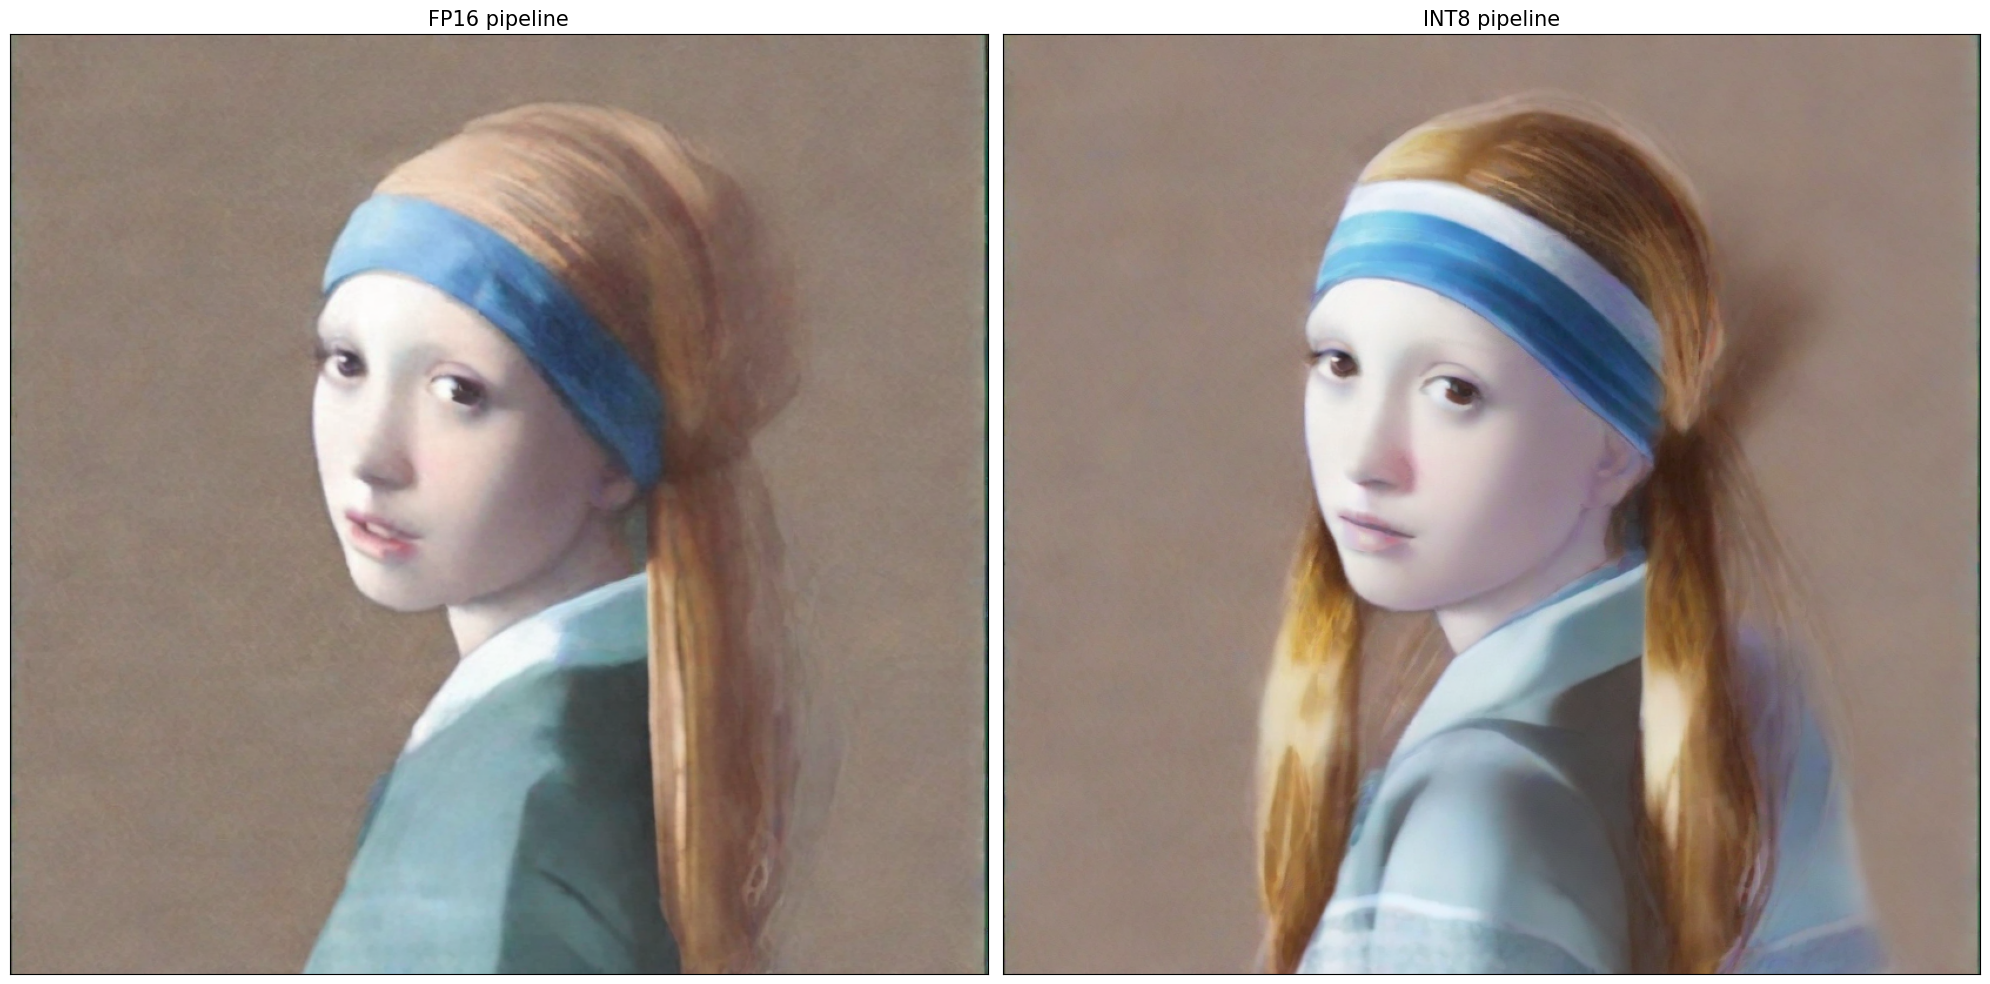

In [42]:
%%skip not $to_quantize.value

visualize_results(image, int8_image)

### Compare model file sizes
[back to top ⬆️](#Table-of-contents:)

In [43]:
%%skip not $to_quantize.value

fp16_model_paths = [ov_unet_path, ov_controlnet_path, ov_text_encoder_path, ov_text_encoder_2_path, ov_vae_decoder_path]
int8_model_paths = [ov_int8_unet_path, ov_int8_controlnet_path, ov_int8_text_encoder_path, ov_int8_text_encoder_2_path, ov_int8_vae_decoder_path]

for fp16_path, int8_path in zip(fp16_model_paths, int8_model_paths):
    fp16_ir_model_size = fp16_path.with_suffix(".bin").stat().st_size
    int8_model_size = int8_path.with_suffix(".bin").stat().st_size
    print(f"{fp16_path.stem} compression rate: {fp16_ir_model_size / int8_model_size:.3f}")

unet compression rate: 1.995
controlnet compression rate: 1.992
text_encoder compression rate: 1.992
text_encoder_2 compression rate: 1.995
vae_decoder compression rate: 1.997


### Compare inference time of the FP16 and INT8 pipelines
[back to top ⬆️](#Table-of-contents:)

To measure the inference performance of the `FP16` and `INT8` pipelines, we use mean inference time on 5 samples.

Please select below whether you would like to run inference time comparison.

> **NOTE**: For the most accurate performance estimation, it is recommended to run `benchmark_app` in a terminal/command prompt after closing other applications.

> **NOTE**: This is a memory consuming step because two pipelines need to be loaded at the same time.

In [ ]:
import ipywidgets as widgets

run_inference_time_comparison = widgets.Checkbox(
    value=False,
    description="Inference time comparison",
    disabled=not to_quantize.value,
)

run_inference_time_comparison

In [44]:
%%skip (not $to_quantize.value or not $run_inference_time_comparison.value)

import time

def calculate_inference_time(pipeline, face_info):
    inference_time = []
    pipeline.set_progress_bar_config(disable=True)
    for i in range(5):
        face_emb, face_kps = face_info[i]
        prompt = np.random.choice(prompts)
        negative_prompt = np.random.choice(negative_prompts)
        start = time.perf_counter()
        _ = pipeline(
            prompt,
            image_embeds=face_emb,
            image=face_kps,
            num_inference_steps=4,
            negative_prompt=negative_prompt,
            guidance_scale=0.5,
            generator=torch.Generator(device="cpu").manual_seed(1749781188)
        )
        end = time.perf_counter()
        delta = end - start
        inference_time.append(delta)
    pipeline.set_progress_bar_config(disable=False)
    return np.mean(inference_time)

In [ ]:
%%skip (not $to_quantize.value or not $run_inference_time_comparison.value)

# Load full precision pipeline
ov_pipe = create_ov_pipe(
    ov_text_encoder_path,
    ov_text_encoder_2_path,
    ov_image_proj_encoder_path,
    ov_controlnet_path,
    ov_unet_path,
    ov_vae_decoder_path,
    MODELS_DIR / "tokenizer",
    MODELS_DIR / "tokenizer_2",
    MODELS_DIR / "scheduler",
)

In [45]:
%%skip (not $to_quantize.value or not $run_inference_time_comparison.value)

fp_latency = calculate_inference_time(ov_pipe, face_info)
print(f"FP16 pipeline: {fp_latency:.3f} seconds")
int8_latency = calculate_inference_time(int8_pipe, face_info)
print(f"INT8 pipeline: {int8_latency:.3f} seconds")
print(f"Performance speed-up: {fp_latency / int8_latency:.3f}")

FP16 pipeline: 20.018 seconds
INT8 pipeline: 20.372 seconds
Performance speed-up: 0.983


## Interactive demo
[back to top ⬆️](#Table-of-contents:)

Please select below whether you would like to use the quantized models to launch the interactive demo.

In [46]:
import ipywidgets as widgets

quantized_models_present = int8_pipe is not None

use_quantized_models = widgets.Checkbox(
    value=quantized_models_present,
    description="Use quantized models",
    disabled=not quantized_models_present,
)

use_quantized_models

Checkbox(value=True, description='Use quantized models')

In [ ]:
if use_quantized_models.value:
    if ov_pipe is not None:
        del ov_pipe
        gc.collect()
elif ov_pipe is None:
    ov_pipe = create_ov_pipe(
        ov_text_encoder_path,
        ov_text_encoder_2_path,
        ov_image_proj_encoder_path,
        ov_controlnet_path,
        ov_unet_path,
        ov_vae_decoder_path,
        MODELS_DIR / "tokenizer",
        MODELS_DIR / "tokenizer_2",
        MODELS_DIR / "scheduler",
    )

In [47]:
import gradio as gr
from typing import Tuple

import PIL
import shutil

orig_style_template_path = Path("InstantID/gradio_demo/style_template.py")
style_template_path = Path(orig_style_template_path.name)
if not style_template_path.exists():
    shutil.copy(orig_style_template_path, style_template_path)

from style_template import styles

# global variables
DEFAULT_STYLE_NAME = "Watercolor"

pipeline = int8_pipe if use_quantized_models.value else ov_pipe


def convert_from_cv2_to_image(img: np.ndarray) -> PIL.Image:
    return Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))


def convert_from_image_to_cv2(img: PIL.Image) -> np.ndarray:
    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)


def resize_img(
    input_image,
    max_side=1024,
    min_side=800,
    size=None,
    pad_to_max_side=False,
    mode=PIL.Image.BILINEAR,
    base_pixel_number=64,
):
    w, h = input_image.size
    if size is not None:
        w_resize_new, h_resize_new = size
    else:
        ratio = min_side / min(h, w)
        w, h = round(ratio * w), round(ratio * h)
        ratio = max_side / max(h, w)
        input_image = input_image.resize([round(ratio * w), round(ratio * h)], mode)
        w_resize_new = (round(ratio * w) // base_pixel_number) * base_pixel_number
        h_resize_new = (round(ratio * h) // base_pixel_number) * base_pixel_number
    input_image = input_image.resize([w_resize_new, h_resize_new], mode)

    if pad_to_max_side:
        res = np.ones([max_side, max_side, 3], dtype=np.uint8) * 255
        offset_x = (max_side - w_resize_new) // 2
        offset_y = (max_side - h_resize_new) // 2
        res[offset_y : offset_y + h_resize_new, offset_x : offset_x + w_resize_new] = np.array(input_image)
        input_image = Image.fromarray(res)
    return input_image


def apply_style(style_name: str, positive: str, negative: str = "") -> Tuple[str, str]:
    p, n = styles.get(style_name, styles[DEFAULT_STYLE_NAME])
    return p.replace("{prompt}", positive), n + " " + negative


def generate_image(
    face_image,
    pose_image,
    prompt,
    negative_prompt,
    style_name,
    num_steps,
    identitynet_strength_ratio,
    guidance_scale,
    seed,
    progress=gr.Progress(track_tqdm=True),
):
    if prompt is None:
        prompt = "a person"

    # apply the style template
    prompt, negative_prompt = apply_style(style_name, prompt, negative_prompt)

    # face_image = load_image(face_image_path)
    face_image = resize_img(face_image)
    face_image_cv2 = convert_from_image_to_cv2(face_image)
    height, width, _ = face_image_cv2.shape

    # Extract face features
    face_info = app.get(face_image_cv2)

    if len(face_info) == 0:
        raise gr.Error("Cannot find any face in the image! Please upload another person image")

    face_info = sorted(
        face_info,
        key=lambda x: (x["bbox"][2] - x["bbox"][0]) * x["bbox"][3] - x["bbox"][1],
    )[
        -1
    ]  # only use the maximum face
    face_emb = face_info["embedding"]
    face_kps = draw_kps(convert_from_cv2_to_image(face_image_cv2), face_info["kps"])

    if pose_image is not None:
        # pose_image = load_image(pose_image_path)
        pose_image = resize_img(pose_image)
        pose_image_cv2 = convert_from_image_to_cv2(pose_image)

        face_info = app.get(pose_image_cv2)

        if len(face_info) == 0:
            raise gr.Error("Cannot find any face in the reference image! Please upload another person image")

        face_info = face_info[-1]
        face_kps = draw_kps(pose_image, face_info["kps"])

        width, height = face_kps.size

    generator = torch.Generator(device="cpu").manual_seed(seed)

    print("Start inference...")
    print(f"[Debug] Prompt: {prompt}, \n[Debug] Neg Prompt: {negative_prompt}")
    images = pipeline(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image_embeds=face_emb,
        image=face_kps,
        controlnet_conditioning_scale=float(identitynet_strength_ratio),
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        height=height,
        width=width,
        generator=generator,
    ).images

    return images[0]

In [ ]:
if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/instant-id/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

from gradio_helper import make_demo

demo = make_demo(fn=generate_image)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(share=True, debug=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/